Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

In [2]:
#Download NTLK Resource
import nltk

nltk.download('stopwords', quiet=True)
nltk.download('vader_lexicon', quiet=True)

True

Load Dataset

In [3]:
df = pd.read_csv("twitter_training.csv", header=None)
df.head()

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       74682 non-null  int64 
 1   1       74682 non-null  object
 2   2       74682 non-null  object
 3   3       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [5]:
df.describe()

,0
count,74682.000000
mean,6432.586165
std,3740.427870
min,1.000000
25%,3195.000000
50%,6422.000000
75%,9601.000000
max,13200.000000


In [6]:
#Assign Proper Column Names
df.columns = ["ID","Topic","Sentiment","Tweet"]
df.head()

,ID,Topic,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


Basic Dataset Exploration

In [7]:
df.shape

(74682, 4)

In [8]:
#Check Missing Values
df.isnull().sum()

ID             0
Topic          0
Sentiment      0
Tweet        686
dtype: int64

In [9]:
#Drop Missing Tweets
df = df.dropna()

In [10]:
df.isnull().sum()

ID           0
Topic        0
Sentiment    0
Tweet        0
dtype: int64

Sentiment Distribution

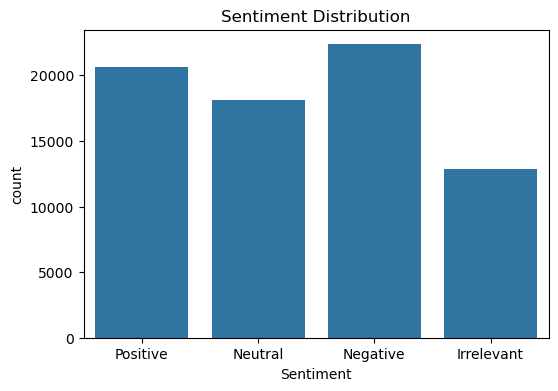

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sentiment", data=df)

plt.title("Sentiment Distribution")
plt.show()

In [12]:
df = df.copy()

Tweet Text Cleaning

In [13]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [14]:
#Apply Cleaning
df.loc[:, "clean_tweet"] = df["Tweet"].apply(clean_text)

df.head()

,ID,Topic,Sentiment,Tweet,clean_tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting borderlands murder
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,coming borders kill
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting borderlands kill
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming borderlands murder
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting borderlands murder


Sentiment Analysis using VADER

In [16]:
sia = SentimentIntensityAnalyzer()

In [17]:
#Calculate Sentiment Scores
df.loc[:, "sentiment_score"] = df["clean_tweet"].apply(lambda x: sia.polarity_scores(x)["compound"])

In [18]:
#Classify Sentiments
def get_sentiment(score):

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df.loc[:, "Predicted_Sentiment"] = df["sentiment_score"].apply(get_sentiment)

df.head()

,ID,Topic,Sentiment,Tweet,clean_tweet,sentiment_score,Predicted_Sentiment
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting borderlands murder,-0.6908,Negative
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,coming borders kill,-0.6908,Negative
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting borderlands kill,-0.6908,Negative
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming borderlands murder,-0.6908,Negative
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting borderlands murder,-0.6908,Negative


Visualize Predicted Sentiments

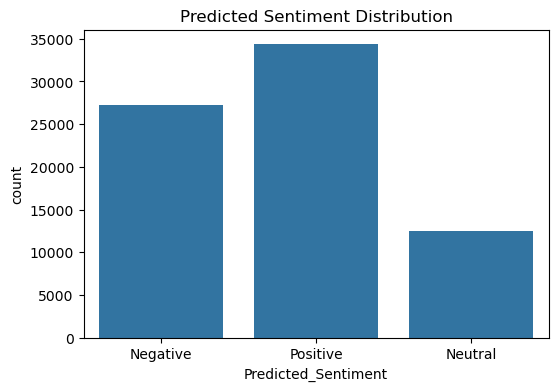

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x="Predicted_Sentiment", data=df)

plt.title("Predicted Sentiment Distribution")

plt.show()

Sentiment by Topic

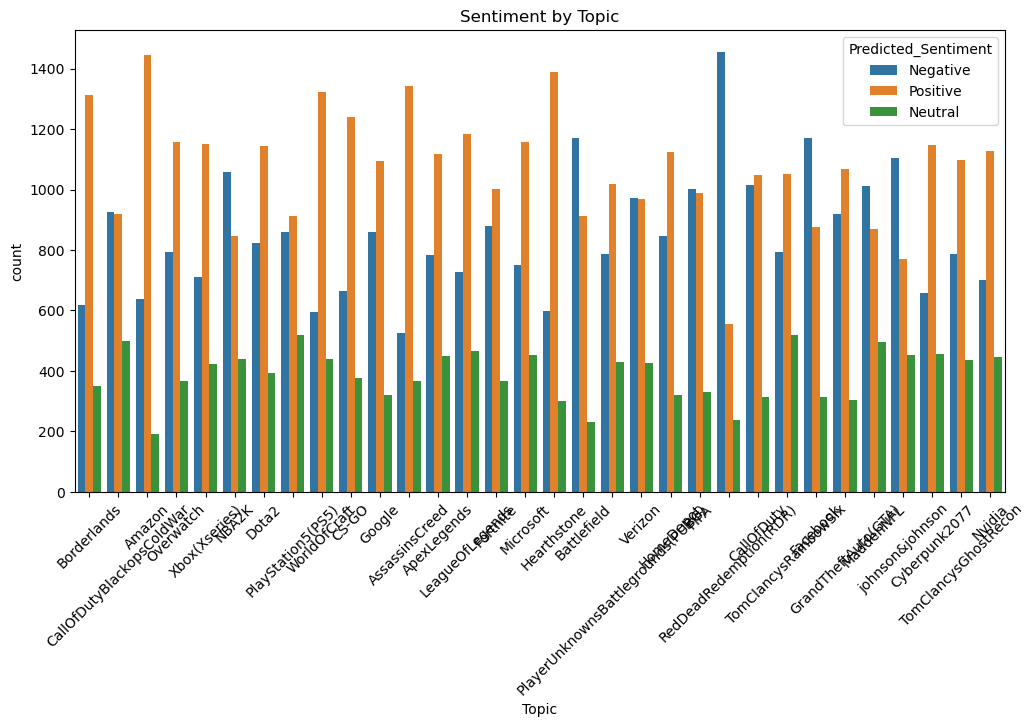

In [20]:
plt.figure(figsize=(12,6))

sns.countplot(data=df, x="Topic", hue="Predicted_Sentiment")

plt.xticks(rotation=45)

plt.title("Sentiment by Topic")

plt.show()

Word Frequency Visualization

In [21]:
from collections import Counter

words = " ".join(df["clean_tweet"]).split()

common_words = Counter(words).most_common(20)

words_df = pd.DataFrame(common_words, columns=["Word","Count"])

words_df

,Word,Count
0,game,8062
1,im,4942
2,like,4882
3,get,3941
4,one,3582
5,good,3552
6,play,3414
7,really,3260
8,love,3239
9,new,3210


In [22]:
#Plot most frequent words
from collections import Counter

words = " ".join(df["clean_tweet"]).split()

common_words = Counter(words).most_common(20)

words_df = pd.DataFrame(common_words, columns=["Word","Count"])

words_df

,Word,Count
0,game,8062
1,im,4942
2,like,4882
3,get,3941
4,one,3582
5,good,3552
6,play,3414
7,really,3260
8,love,3239
9,new,3210
